# Shift Detection Validation

Validate the shift detection algorithm on real Wilmette buoy data. Show detected shifts overlaid on raw wind data.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
from src.buoy_loader import load_buoy_data
from src.shift_detector import detect_shifts

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

Matplotlib is building the font cache; this may take a moment.


## Load Wilmette Buoy Data

In [2]:
# Load 2024 data for Wilmette buoy
df = load_buoy_data('../data/raw/wilmette/45174h2024.txt')
print(f"Loaded {len(df)} readings")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
df.head()

Loaded 19573 readings
Date range: 2024-05-09 17:40:00 to 2024-11-01 19:40:00


,YY,MM,DD,hh,mm,WDIR,WSPD,GST,WVHT,DPD,...,PRES,ATMP,WTMP,DEWP,VIS,TIDE,timestamp,wind_speed_knots,gust_speed_knots,wind_dir_deg
0,2024,5,9,17,40,351.0,7.0,9.3,0.95,3.63,...,1007.9,10.5,12.6,10.3,NaN,NaN,2024-05-09 17:40:00,13.606880,18.077712,351.0
1,2024,5,9,18,50,11.0,7.6,10.8,1.01,3.87,...,1008.3,11.1,12.4,11.0,NaN,NaN,2024-05-09 18:50:00,14.773184,20.993472,11.0
2,2024,5,9,20,0,2.0,6.0,7.9,1.10,4.07,...,1008.9,11.1,12.4,11.1,NaN,NaN,2024-05-09 20:00:00,11.663040,15.356336,2.0
3,2024,5,9,21,10,310.0,8.0,10.4,0.91,4.11,...,1009.8,10.6,12.3,11.2,NaN,NaN,2024-05-09 21:10:00,15.550720,20.215936,310.0
4,2024,5,9,22,20,310.0,7.9,10.9,1.15,4.09,...,1010.9,10.1,12.2,10.1,NaN,NaN,2024-05-09 22:20:00,15.356336,21.187856,310.0


## Detect Shifts

In [3]:
# Run shift detector
events = detect_shifts(df, buoy_id='45174')
print(f"\nDetected {len(events)} persistent shifts")

# Convert to DataFrame for easier analysis
events_df = pd.DataFrame([{
    'timestamp': e.timestamp,
    'baseline_dir': e.baseline_direction,
    'new_dir': e.new_direction,
    'magnitude': e.magnitude,
    'wind_speed': e.wind_speed,
    'veering': e.veering
} for e in events])

if len(events_df) > 0:
    print(f"\nShift magnitude range: {events_df['magnitude'].min():.1f}° - {events_df['magnitude'].max():.1f}°")
    print(f"Wind speed range: {events_df['wind_speed'].min():.1f} - {events_df['wind_speed'].max():.1f} knots")
    print(f"Veering shifts: {events_df['veering'].sum()}")
    print(f"Backing shifts: {(~events_df['veering']).sum()}")


Detected 142 persistent shifts

Shift magnitude range: 10.0° - 39.6°
Wind speed range: 5.4 - 23.1 knots
Veering shifts: 85
Backing shifts: 57


## First 10 Detected Shift Events

In [4]:
if len(events_df) > 0:
    display(events_df.head(10))
else:
    print("No shifts detected in this dataset")

,timestamp,baseline_dir,new_dir,magnitude,wind_speed,veering
0,2024-06-10 05:00:00,326.664566,338.0,11.335434,15.161952,True
1,2024-06-10 09:20:00,329.500965,317.0,12.500965,13.606880,False
2,2024-06-10 09:40:00,326.836691,316.0,10.836691,14.190032,False
3,2024-06-10 14:20:00,322.917769,309.0,13.917769,14.578800,False
4,2024-06-10 17:30:00,327.248291,340.0,12.751709,11.079888,True
5,2024-06-10 20:40:00,346.666086,336.0,10.666086,11.274272,False
6,2024-06-10 23:50:00,338.167132,325.0,13.167132,5.637136,False
7,2024-06-21 02:40:00,320.002747,332.0,11.997253,8.747280,True
8,2024-06-23 21:20:00,338.333389,322.0,16.333389,6.414672,False
9,2024-06-24 18:20:00,42.417135,57.0,14.582865,6.025904,True


## Visualize Shifts Over Time

Plot wind direction time series with detected shifts marked.

Plotting 2024-06 with 16 detected shifts


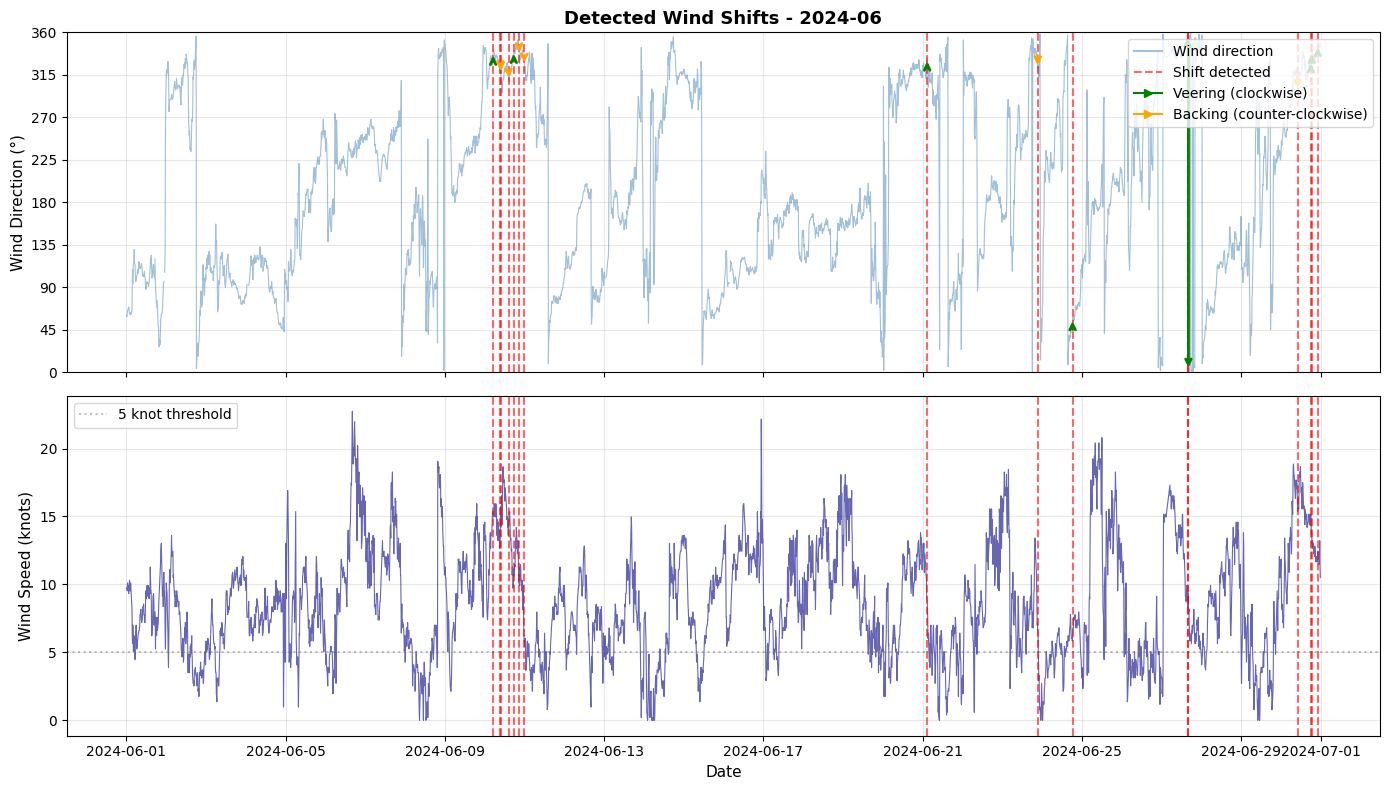

In [5]:
# Focus on a month with detected shifts for clearer visualization
if len(events_df) > 0:
    # Pick June 2024 if available, or first month with shifts
    sample_month = events_df['timestamp'].iloc[0].to_period('M')
    mask = (df['timestamp'] >= sample_month.start_time) & (df['timestamp'] <= sample_month.end_time)
    df_month = df[mask].copy()
    events_month = events_df[
        (events_df['timestamp'] >= sample_month.start_time) & 
        (events_df['timestamp'] <= sample_month.end_time)
    ]
    
    print(f"Plotting {sample_month} with {len(events_month)} detected shifts")
    
    # Create figure with 2 subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    
    # Plot 1: Wind direction
    ax1.plot(df_month['timestamp'], df_month['wind_dir_deg'], 
             color='steelblue', alpha=0.5, linewidth=0.8, label='Wind direction')
    
    # Mark detected shifts
    for _, event in events_month.iterrows():
        ax1.axvline(event['timestamp'], color='red', alpha=0.6, linestyle='--', linewidth=1.5)
        # Add arrow showing shift direction
        arrow_color = 'green' if event['veering'] else 'orange'
        ax1.annotate('', xy=(event['timestamp'], event['new_dir']),
                    xytext=(event['timestamp'], event['baseline_dir']),
                    arrowprops=dict(arrowstyle='->', color=arrow_color, lw=2))
    
    ax1.set_ylabel('Wind Direction (°)', fontsize=11)
    ax1.set_ylim(0, 360)
    ax1.set_yticks([0, 45, 90, 135, 180, 225, 270, 315, 360])
    ax1.grid(True, alpha=0.3)
    ax1.set_title(f'Detected Wind Shifts - {sample_month}', fontsize=13, fontweight='bold')
    
    # Add legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='steelblue', alpha=0.5, label='Wind direction'),
        Line2D([0], [0], color='red', linestyle='--', alpha=0.6, label='Shift detected'),
        Line2D([0], [0], color='green', marker='>', linestyle='-', label='Veering (clockwise)'),
        Line2D([0], [0], color='orange', marker='>', linestyle='-', label='Backing (counter-clockwise)')
    ]
    ax1.legend(handles=legend_elements, loc='upper right')
    
    # Plot 2: Wind speed
    ax2.plot(df_month['timestamp'], df_month['wind_speed_knots'], 
             color='navy', alpha=0.6, linewidth=0.8)
    ax2.axhline(5.0, color='gray', linestyle=':', alpha=0.5, label='5 knot threshold')
    
    # Mark shifts on wind speed plot
    for _, event in events_month.iterrows():
        ax2.axvline(event['timestamp'], color='red', alpha=0.6, linestyle='--', linewidth=1.5)
    
    ax2.set_xlabel('Date', fontsize=11)
    ax2.set_ylabel('Wind Speed (knots)', fontsize=11)
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
else:
    print("No shifts to visualize")

## Shift Magnitude Distribution

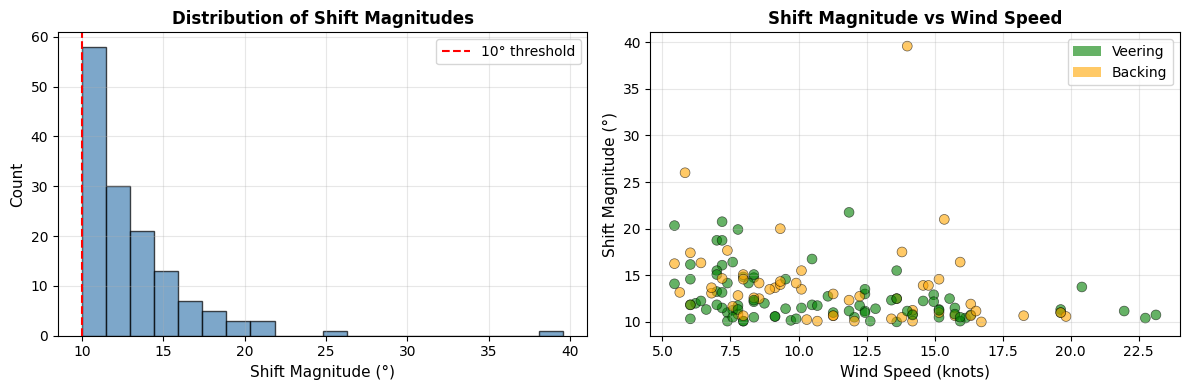

In [6]:
if len(events_df) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histogram of shift magnitudes
    ax1.hist(events_df['magnitude'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    ax1.axvline(10.0, color='red', linestyle='--', label='10° threshold')
    ax1.set_xlabel('Shift Magnitude (°)', fontsize=11)
    ax1.set_ylabel('Count', fontsize=11)
    ax1.set_title('Distribution of Shift Magnitudes', fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Shift magnitude vs wind speed
    colors = ['green' if v else 'orange' for v in events_df['veering']]
    ax2.scatter(events_df['wind_speed'], events_df['magnitude'], 
                c=colors, alpha=0.6, s=50, edgecolor='black', linewidth=0.5)
    ax2.set_xlabel('Wind Speed (knots)', fontsize=11)
    ax2.set_ylabel('Shift Magnitude (°)', fontsize=11)
    ax2.set_title('Shift Magnitude vs Wind Speed', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    # Add legend for veering/backing
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='green', alpha=0.6, label='Veering'),
        Patch(facecolor='orange', alpha=0.6, label='Backing')
    ]
    ax2.legend(handles=legend_elements)
    
    plt.tight_layout()
    plt.show()

## Summary Statistics

In [7]:
if len(events_df) > 0:
    print("Shift Detection Summary:")
    print(f"Total shifts detected: {len(events_df)}")
    print(f"\nMagnitude (degrees):")
    print(f"  Mean: {events_df['magnitude'].mean():.1f}°")
    print(f"  Median: {events_df['magnitude'].median():.1f}°")
    print(f"  Std dev: {events_df['magnitude'].std():.1f}°")
    print(f"\nWind speed at shift (knots):")
    print(f"  Mean: {events_df['wind_speed'].mean():.1f}")
    print(f"  Median: {events_df['wind_speed'].median():.1f}")
    print(f"\nShift direction:")
    print(f"  Veering (clockwise): {events_df['veering'].sum()} ({100*events_df['veering'].mean():.1f}%)")
    print(f"  Backing (counter-clockwise): {(~events_df['veering']).sum()} ({100*(~events_df['veering']).mean():.1f}%)")

Shift Detection Summary:
Total shifts detected: 142

Magnitude (degrees):
  Mean: 13.1°
  Median: 12.0°
  Std dev: 3.6°

Wind speed at shift (knots):
  Mean: 11.1
  Median: 10.1

Shift direction:
  Veering (clockwise): 85 (59.9%)
  Backing (counter-clockwise): 57 (40.1%)
